In [1]:
import earthaccess
import odc.stac
import pyproj
import pystac
import pystac_client
from shapely.geometry import box
from shapely.ops import transform

In [2]:
catalog = pystac_client.Client.open("https://cmr.earthdata.nasa.gov/stac/LPCLOUD")

HLS_COLLECTION_IDS = ["HLSL30_2.0", "HLSS30_2.0"]

URL_PREFIX = "https://data.lpdaac.earthdatacloud.nasa.gov/"

In [3]:
auth = earthaccess.login(strategy="interactive", persist=True)
s3_creds = auth.get_s3_credentials("LPDAAC")

odc.stac.configure_rio(
    cloud_defaults=True,
    aws=dict(
        aws_access_key_id=s3_creds["accessKeyId"],
        aws_secret_access_key=s3_creds["secretAccessKey"],
        aws_session_token=s3_creds["sessionToken"],
        region_name="us-west-2",
    )
)

In [4]:
# my CRS of choice for CONUS these days
CRS_STRING = "epsg:5070"
EPSG = pyproj.CRS.from_string(CRS_STRING).to_epsg()

START_DATE = "2024-01-01"
END_DATE = "2024-12-31"

def convert_to_s3_uri(url: str) -> str:
    return url.replace(
        URL_PREFIX,
        "s3://"
    )

# 100 km bounding box
xmin, ymin = 250000, 2750000
bbox = (xmin, ymin, xmin + 100000, ymin + 100000)
aoi = box(*bbox)

# STAC items store bounding box info in epsg:4326
transformer_4326 = pyproj.Transformer.from_crs(
    crs_from=CRS_STRING,
    crs_to="epsg:4326",
    always_xy=True,
)

bbox_4326 = transform(transformer_4326.transform, aoi).bounds

In [5]:
item_collection_json = "hls_items.json"

# stac_items = catalog.search(
#     collections=HLS_COLLECTION_IDS,
#     bbox=bbox_4326,
#     datetime=[START_DATE, END_DATE],
#     limit=1000,
# ).item_collection()

# stac_items.save_object(item_collection_json)

stac_items = pystac.ItemCollection.from_file(item_collection_json)

print(len(stac_items))

772


In [6]:
for item in stac_items:
    for asset in item.assets.values():
        if asset.href.startswith(URL_PREFIX):
            asset.href = convert_to_s3_uri(asset.href)

stac_items[0].assets["B04"].href

's3://lp-prod-protected/HLSS30.020/HLS.S30.T15UWP.2024004T171711.v2.0/HLS.S30.T15UWP.2024004T171711.v2.0.B04.tif'

In [7]:
stac_items[0]

<Item id=HLS.S30.T15UWP.2024004T171711.v2.0>

In [8]:
def group_by_sensor_and_date(
    item: pystac.Item,
    parsed: odc.stac.ParsedItem,
    idx: int,
) -> str:
    id_split = item.id.split(".")
    sensor = id_split[1]
    day = id_split[3][:7]

    return f"{sensor}_{day}"

In [9]:
HLS_ODC_STAC_CONFIG = {
    "HLSL30_2.0": {
        "assets": {
            "*": {
                "nodata": -9999,
                "data_type": "int16",
            },
            "Fmask": {
                "nodata": 0,
                "data_type": "uint8",
            },
        },
        "aliases": {
            "coastal_aerosol": "B01",
            "blue": "B02",
            "green": "B03",
            "red": "B04",
            "nir_narrow": "B05",
            "swir_1": "B06",
            "swir_2": "B07",
            "cirrus": "B09",
            "thermal_infrared_1": "B10",
            "thermal": "B11",
        },
    },
    "HLSS30_2.0": {
        "assets": {
            "*": {
                "nodata": -9999,
                "dtype": "int16",
            },
            "Fmask": {
                "nodata": 0,
                "dtype": "uint8",
            },
        },
        "aliases": {
            "coastal_aerosol": "B01",
            "blue": "B02",
            "green": "B03",
            "red": "B04",
            "red_edge_1": "B05",
            "red_edge_2": "B06",
            "red_edge_3": "B07",
            "nir_broad": "B08",
            "nir_narrow": "B8A",
            "water_vapor": "B09",
            "cirrus": "B10",
            "swir_1": "B11",
            "swir_2": "B12",
        },
    },
}

# these are the ones that we are going to use
BANDS = ["red", "green", "blue", "Fmask"]

stack = odc.stac.load(
    stac_items,
    stac_cfg=HLS_ODC_STAC_CONFIG,
    bands=BANDS,
    crs=CRS_STRING,
    resolution=150,
    chunks={},  # <-- use Dask
    groupby=group_by_sensor_and_date,
    x=(bbox[0], bbox[2]),
    y=(bbox[1], bbox[3]),
    patch_url=convert_to_s3_uri,
).sortby("time")
display(stack)

<xarray.Dataset> Size: 2GB
Dimensions:      (y: 667, x: 668, time: 230)
Coordinates:
  * y            (y) float64 5kB 2.85e+06 2.85e+06 ... 2.75e+06 2.75e+06
  * x            (x) float64 5kB 2.5e+05 2.501e+05 ... 3.499e+05 3.5e+05
    spatial_ref  int32 4B 5070
  * time         (time) datetime64[ns] 2kB 2024-01-04T17:20:15.801000 ... 202...
Data variables:
    red          (time, y, x) float32 410MB dask.array<chunksize=(1, 667, 668), meta=np.ndarray>
    green        (time, y, x) float32 410MB dask.array<chunksize=(1, 667, 668), meta=np.ndarray>
    blue         (time, y, x) float32 410MB dask.array<chunksize=(1, 667, 668), meta=np.ndarray>
    Fmask        (time, y, x) float32 410MB dask.array<chunksize=(1, 667, 668), meta=np.ndarray>

In [19]:
(
    stack.to_dataarray(dim="band").sel(
        time=slice("2024-06-01", "2024-06-30"),
        band=["red", "green", "blue"]
    )
    .plot.imshow(
        rgb="band",
        col="time",
        col_wrap=3,
        robust=True,
        vmin=0,
        vmax=1000,
    )
)

AttributeError: 'DatasetPlotAccessor' object has no attribute 'imshow'

In [10]:
hls_mask_bitfields = [1, 2, 3]  # cloud shadow, adjacent to cloud shadow, cloud
hls_bitmask = 0
for field in hls_mask_bitfields:
    hls_bitmask |= 1 << field

print(hls_bitmask)

14


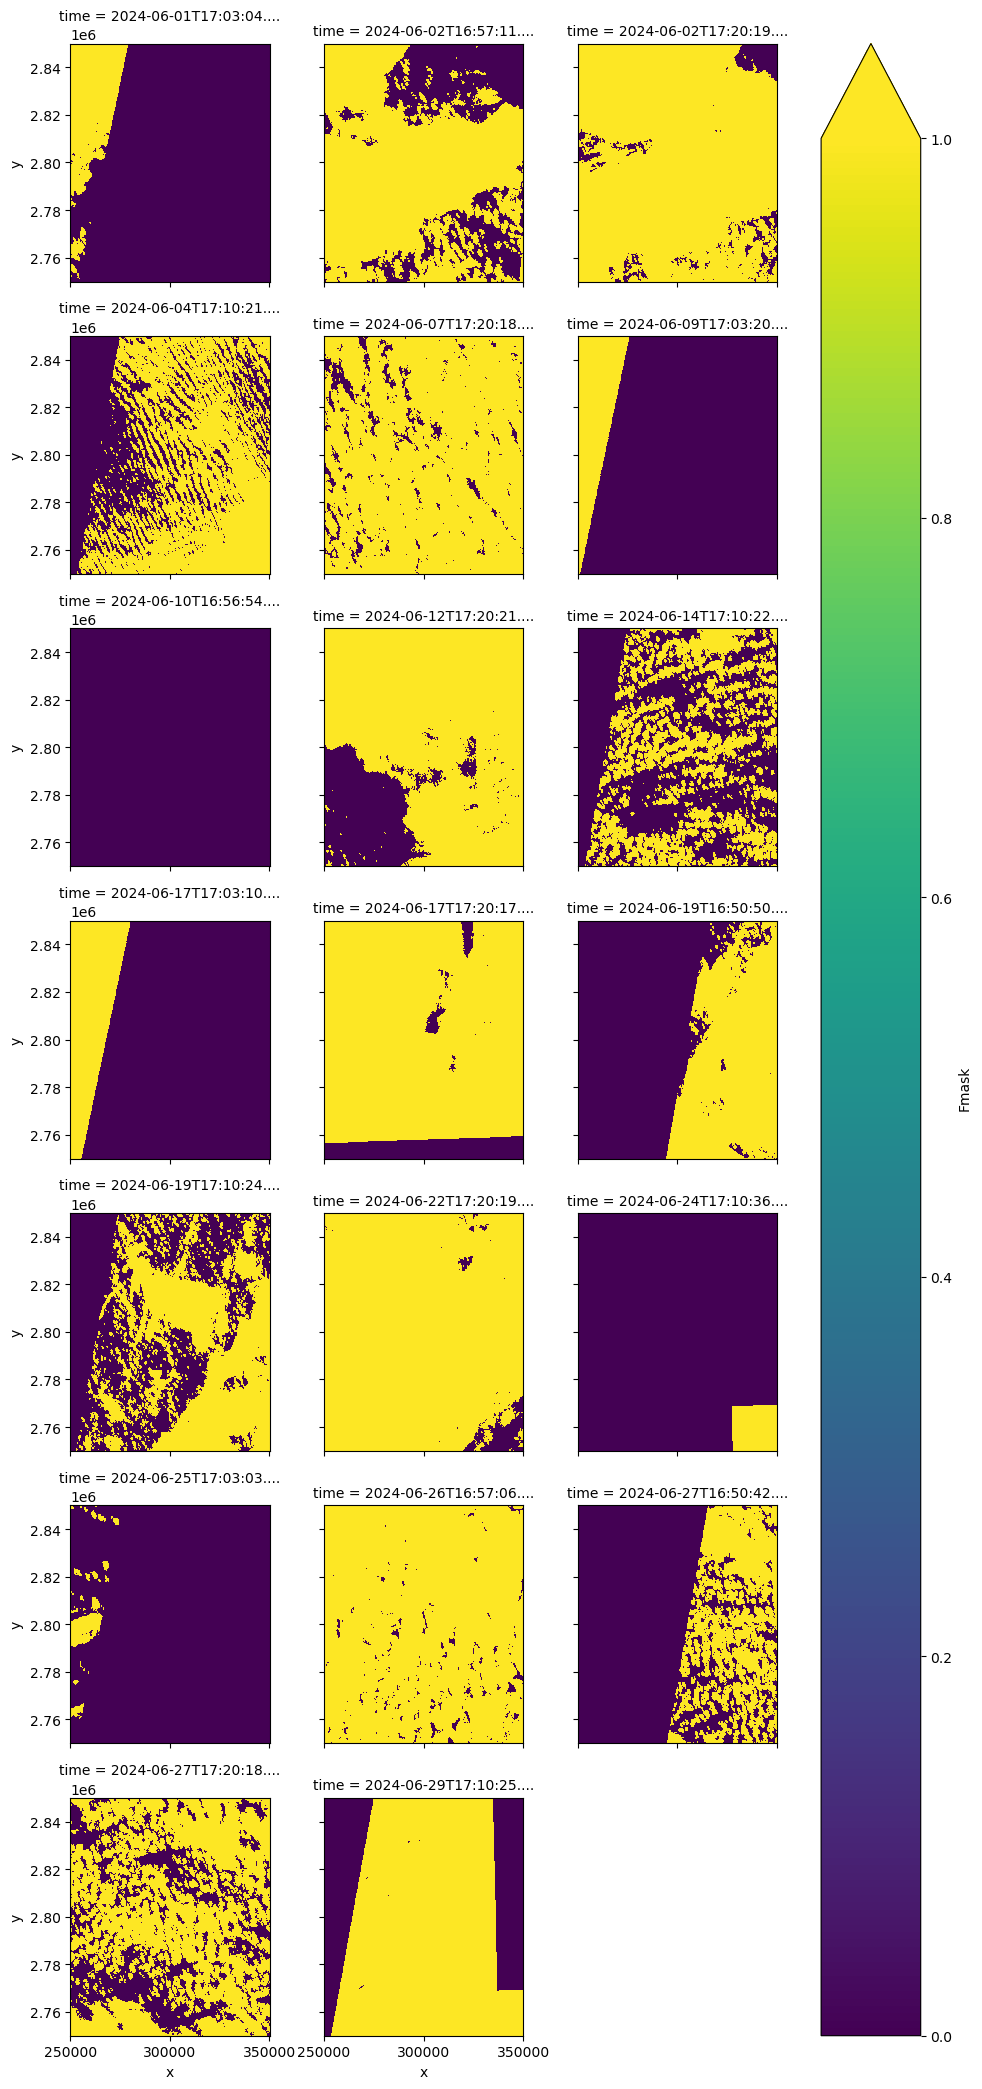

In [13]:
fmask = stack["Fmask"].astype("uint16")
mask = fmask & hls_bitmask

(
    mask.sel(
        time=slice("2024-06-01", "2024-06-30"),
    ).plot.imshow(
        col="time",
        col_wrap=3,
        vmin=0,
        vmax=1,
        cmap="viridis",
    )
)

In [20]:
cloud_free = stack.where(mask == 0).where(stack != -9999)

monthly_cloud_free = cloud_free.resample(time="1M").median(skipna=True)
monthly_cloud_free

<xarray.Dataset> Size: 86MB
Dimensions:      (time: 12, y: 667, x: 668)
Coordinates:
  * y            (y) float64 5kB 2.85e+06 2.85e+06 ... 2.75e+06 2.75e+06
  * x            (x) float64 5kB 2.5e+05 2.501e+05 ... 3.499e+05 3.5e+05
    spatial_ref  int32 4B 5070
  * time         (time) datetime64[ns] 96B 2024-01-31 2024-02-29 ... 2024-12-31
Data variables:
    red          (time, y, x) float32 21MB dask.array<chunksize=(1, 667, 668), meta=np.ndarray>
    green        (time, y, x) float32 21MB dask.array<chunksize=(1, 667, 668), meta=np.ndarray>
    blue         (time, y, x) float32 21MB dask.array<chunksize=(1, 667, 668), meta=np.ndarray>
    Fmask        (time, y, x) float32 21MB dask.array<chunksize=(1, 667, 668), meta=np.ndarray>

In [ ]:
%%time
monthly_cloud_free.load()

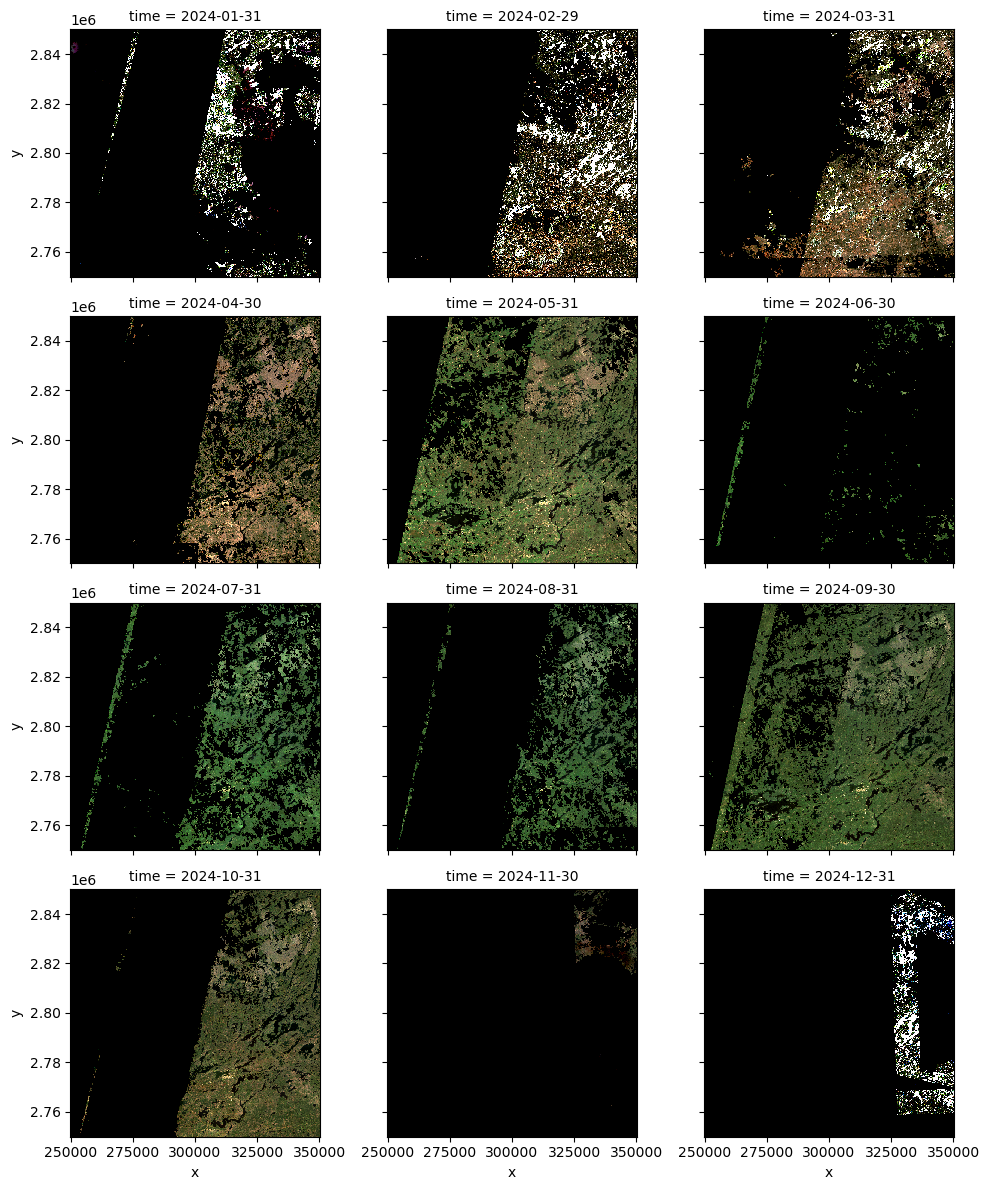

In [18]:
(
    monthly_cloud_free.to_dataarray(dim="band").sel(
        band=["red", "green", "blue"]
    ).plot.imshow(
        rgb="band",
        col="time",
        col_wrap=3,
        robust=True,
        vmin=0,
        vmax=1000,
    )
)